# 02 — Time Domain Analysis
### Phần đầu của mục 0.2 — So sánh dạng sóng miền thời gian

**Mục đích**: so sánh trực quan dạng sóng của 4 nhãn (Normal, Inner Race,
Outer Race, Ball) tại **cùng một mức tải**, quan sát sự khác biệt về biên
độ và tính xung (impulsiveness) — lỗi cơ khí thường biểu hiện dưới dạng
các xung lặp lại theo chu kỳ, trong khi Normal thì không.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from common import io_utils, pipeline
pd.set_option("display.max_colwidth", 120)

In [2]:
# ============================== CẤU HÌNH ==============================
# Đổi USE_SYNTHETIC_DATA = False và chỉnh REAL_DATA_ROOT khi đã có dữ liệu
# CWRU thật. Xem README.md phần "Chuyển sang dữ liệu thật".
USE_SYNTHETIC_DATA = True
REAL_DATA_ROOT = Path("../../data/raw")            # <-- de_tai_nckh/data/raw/
SYNTHETIC_DATA_ROOT = Path("./_data/synthetic_cwru")
OUTPUT_DIR = Path("./outputs")
FORCE_REBUILD_MANIFEST = False
# ========================================================================

In [3]:
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

> ⚠️ **Lưu ý dữ liệu giả lập**: khi `USE_SYNTHETIC_DATA = True`, mọi tín hiệu
> trong notebook này là **giả lập** (nhiễu + xung điều biên mô phỏng), chỉ để
> kiểm tra code chạy đúng và xem trước hình dạng đầu ra. **Không dùng số liệu
> giả lập này làm kết quả báo cáo chính thức.** Khi có dữ liệu CWRU thật, đổi
> `USE_SYNTHETIC_DATA = False` ở cell CẤU HÌNH và chạy lại toàn bộ notebook.

In [4]:
manifest = pipeline.get_manifest(
    use_synthetic=USE_SYNTHETIC_DATA,
    real_data_root=REAL_DATA_ROOT,
    synthetic_data_root=SYNTHETIC_DATA_ROOT,
    output_dir=OUTPUT_DIR,
    force_rebuild=FORCE_REBUILD_MANIFEST,
)
print(f"Tổng số file trong manifest: {len(manifest)}")
manifest.head()

Tổng số file trong manifest: 40


,file_path,load_hp,label,fault_diameter_mils,or_position,n_samples_DE,n_samples_FE,n_samples_BA,rpm_from_file,read_error,warnings,has_warning
0,_data/synthetic_cwru/0hp/B_007.mat,0,B,7.0,NaN,120000,NaN,NaN,1797.0,NaN,NaN,False
1,_data/synthetic_cwru/0hp/B_014.mat,0,B,14.0,NaN,120000,NaN,NaN,1797.0,NaN,NaN,False
2,_data/synthetic_cwru/0hp/B_021.mat,0,B,21.0,NaN,120000,NaN,NaN,1797.0,NaN,NaN,False
3,_data/synthetic_cwru/0hp/IR_007.mat,0,IR,7.0,NaN,120000,NaN,NaN,1797.0,NaN,NaN,False
4,_data/synthetic_cwru/0hp/IR_014.mat,0,IR,14.0,NaN,120000,NaN,NaN,1797.0,NaN,NaN,False


## Chọn 1 file đại diện mỗi nhãn, cùng mức tải

In [5]:
LOAD_HP = 0  # đổi mức tải muốn xem tại đây

labels_to_plot = ["Normal", "IR", "OR", "B"]
signals = {}
for label in labels_to_plot:
    fp = pipeline.pick_file(manifest, label=label, load_hp=LOAD_HP)
    signals[label] = io_utils.load_de_signal(Path(fp))
    print(f"{label:8s}: {fp}  ({len(signals[label])} mẫu)")

Normal  : _data/synthetic_cwru/0hp/Normal.mat  (120000 mẫu)
IR      : _data/synthetic_cwru/0hp/IR_007.mat  (120000 mẫu)
OR      : _data/synthetic_cwru/0hp/OR_007_Centered.mat  (120000 mẫu)
B       : _data/synthetic_cwru/0hp/B_007.mat  (120000 mẫu)


## Vẽ chồng dạng sóng thời gian

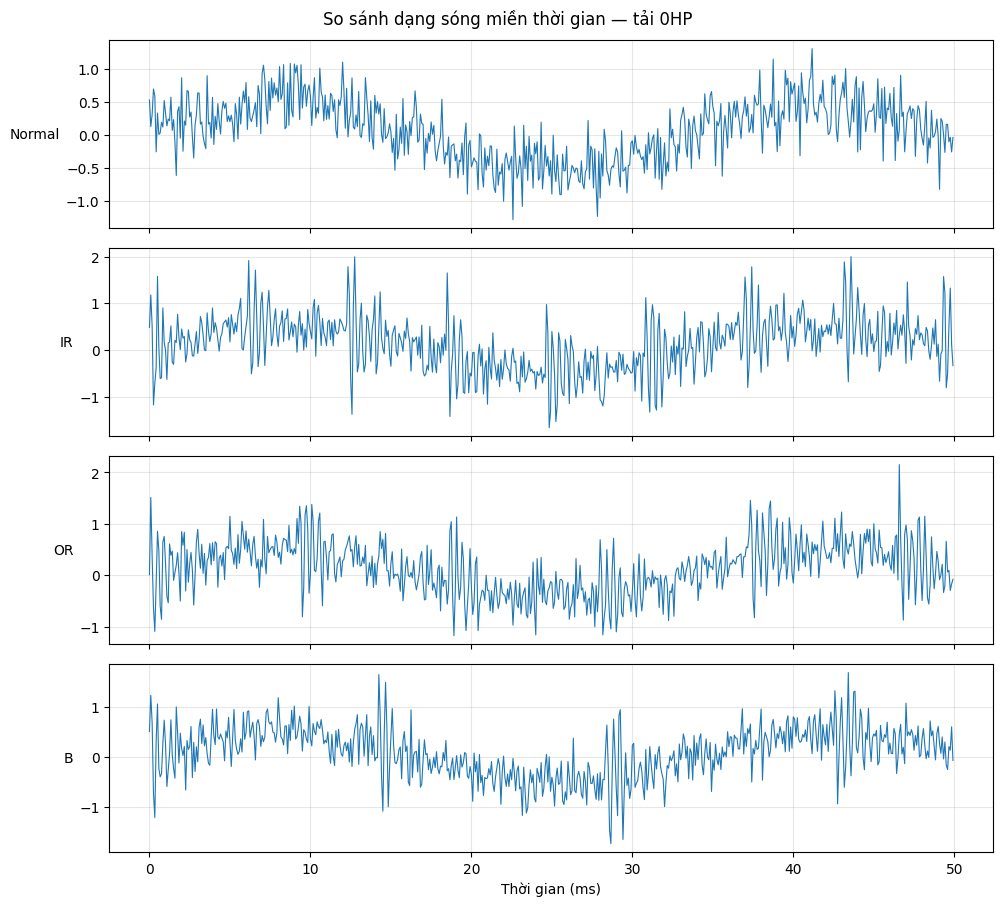

In [6]:
FS = 12000  # sampling rate của dữ liệu đang phân tích (đổi nếu khác)
N_SECONDS = 0.05  # chỉ xem 50ms đầu cho dễ quan sát tính xung

fig, axes = plt.subplots(len(signals), 1, figsize=(10, 2.3 * len(signals)), sharex=True)
n_samples_plot = int(N_SECONDS * FS)
t_ms = np.arange(n_samples_plot) / FS * 1000

for ax, (label, x) in zip(axes, signals.items()):
    ax.plot(t_ms, x[:n_samples_plot], linewidth=0.8)
    ax.set_ylabel(label, rotation=0, ha="right", va="center")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Thời gian (ms)")
fig.suptitle(f"So sánh dạng sóng miền thời gian — tải {LOAD_HP}HP")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_time_domain_comparison.png", dpi=150)
plt.show()

## Quan sát

Điền nhận xét thực tế sau khi chạy với dữ liệu CWRU thật:
- Nhãn nào có biên độ đỉnh (peak) lớn nhất?
- Nhãn nào thể hiện rõ tính xung (các đỉnh nhọn lặp lại theo chu kỳ) nhất?
- Normal có đặc điểm gì khác biệt rõ rệt so với 3 nhãn lỗi?

Hình đã lưu tại `outputs/figures/02_time_domain_comparison.png` — dùng
trực tiếp cho phần Cơ sở lý thuyết của báo cáo.